In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train=pd.read_csv('/content/drive/MyDrive/akbank/train.csv')
test=pd.read_csv('/content/drive/MyDrive/akbank/test.csv')

print("Train veri seti boyutu:",train.shape)
print("Test veri seti boyutu:",test.shape)
train.head()

Train veri seti boyutu: (1460, 81)
Test veri seti boyutu: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
missing=train.isnull().sum()
missing[missing>0].sort_values(ascending=False)


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


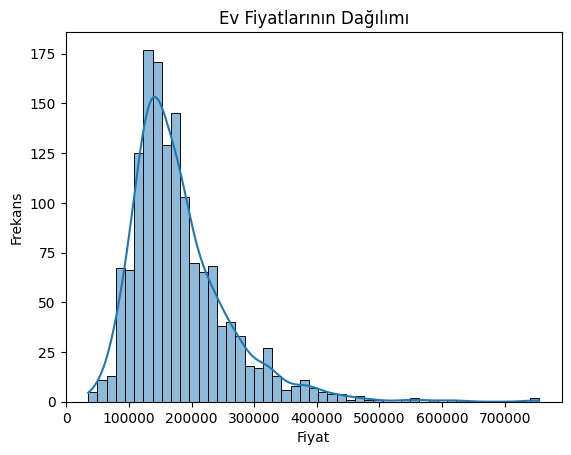

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train['SalePrice'],kde=True)
plt.title("Ev Fiyatlarının Dağılımı")
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.show()

In [ ]:
correlation=train.corr(numeric_only=True)
top_corr_features=correlation['SalePrice'].sort_values(ascending=False)[1:11]
print(top_corr_features)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [ ]:
train.fillna(0,inplace=True)
test.fillna(0,inplace=True)

train=pd.get_dummies(train)
test=pd.get_dummies(test)

train,test=train.align(test,join='inner',axis=1)

print("Ön işleme tamamlandı.Yeni trainshape:",train.shape)


Ön işleme tamamlandı.Yeni trainshape: (1460, 285)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train=pd.read_csv('/content/drive/MyDrive/akbank/train.csv')
test=pd.read_csv('/content/drive/MyDrive/akbank/test.csv')


In [ ]:
y=train['SalePrice']
X=train.drop('SalePrice',axis=1)

In [ ]:
X=X.fillna(0)
test=test.fillna(0)

X=pd.get_dummies(X)
test=pd.get_dummies(test)

X,test=X.align(test,join='left',axis=1)
test=test.fillna(0)

In [ ]:
from sklearn.metrics import mean_squared_error

mse=mean_squared_error(y_val,y_pred)
rmse=mse ** 0.5
print(f"Doğrulama RMSE: {rmse:.2f}")

Doğrulama RMSE: 28985.73


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

model=RandomForestRegressor(random_state=42)

model.fit(x_train, y_train)

NameError: name 'X' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error

y_pred=model.predict(x_val)


mse=mean_squared_error(y_val,y_pred)
rmse=mse **0.5

print(f"Doğrulama RMSE:{rmse:.2f}")

Doğrulam RMSE:28985.73


In [ ]:
model.fit(X,y)

test_preds=model.predict(test)

submission=pd.DataFrame({
    'Id':test['Id'],
    'SalePrice':test_preds
})

submission.to_csv('submission.csv',index=False)
print("Tahminler submission.csv dosyasına kaydedildi.")

Tahminler submission.csv dosyasına kaydedildi.


In [ ]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>